In [50]:
import pandas as pd
df=pd.read_csv("HotelBookings.csv")

In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 26 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   stays_in_weekend_nights         119390 non-null  int64  
 4   stays_in_week_nights            119390 non-null  int64  
 5   adults                          119390 non-null  int64  
 6   children                        119386 non-null  float64
 7   babies                          119390 non-null  int64  
 8   meal                            119390 non-null  object 
 9   is_repeated_guest               119390 non-null  int64  
 10  previous_cancellations          119390 non-null  int64  
 11  previous_bookings_not_canceled  119390 non-null  int64  
 12  reserved_room_ty

In [52]:
df.isnull().sum()

hotel                                  0
is_canceled                            0
lead_time                              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company                           112593
days_in_waiting_list                   0
customer_type                          0
adr                                    0
required_car_parking_spaces            0
total_of_special_requests              0
reservation_status                     0
reservation_stat

In [53]:
df.dropna(inplace=True)

In [54]:
drop1=["lead_time","days_in_waiting_list","adr","agent","company","reservation_status_date","arrival_date","is_canceled","assigned_room_type","booking_changes","total_of_special_requests","meal"]
df.drop(columns=drop1,inplace=True)

In [55]:
from sklearn.preprocessing import LabelEncoder
df=df.apply(LabelEncoder().fit_transform)

In [56]:
df[list(df)].apply(lambda y:y.astype("category"))

,hotel,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,deposit_type,customer_type,required_car_parking_spaces,reservation_status
2392,1,2,0,1,0,0,0,0,0,3,0,2,1,1
2697,1,6,11,0,0,0,0,0,0,3,0,3,0,1
2867,1,0,3,1,0,0,0,0,0,0,0,3,0,1
2877,1,2,10,0,0,0,0,0,0,0,0,3,0,1
2878,1,3,10,1,0,0,0,0,0,0,0,3,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112499,0,0,1,1,0,0,0,0,0,0,0,3,0,1
113046,0,1,3,0,0,0,0,0,0,0,0,2,0,1
113082,0,1,3,1,0,0,0,0,0,0,0,2,0,1
113627,0,0,1,1,0,0,0,0,0,2,0,2,0,1


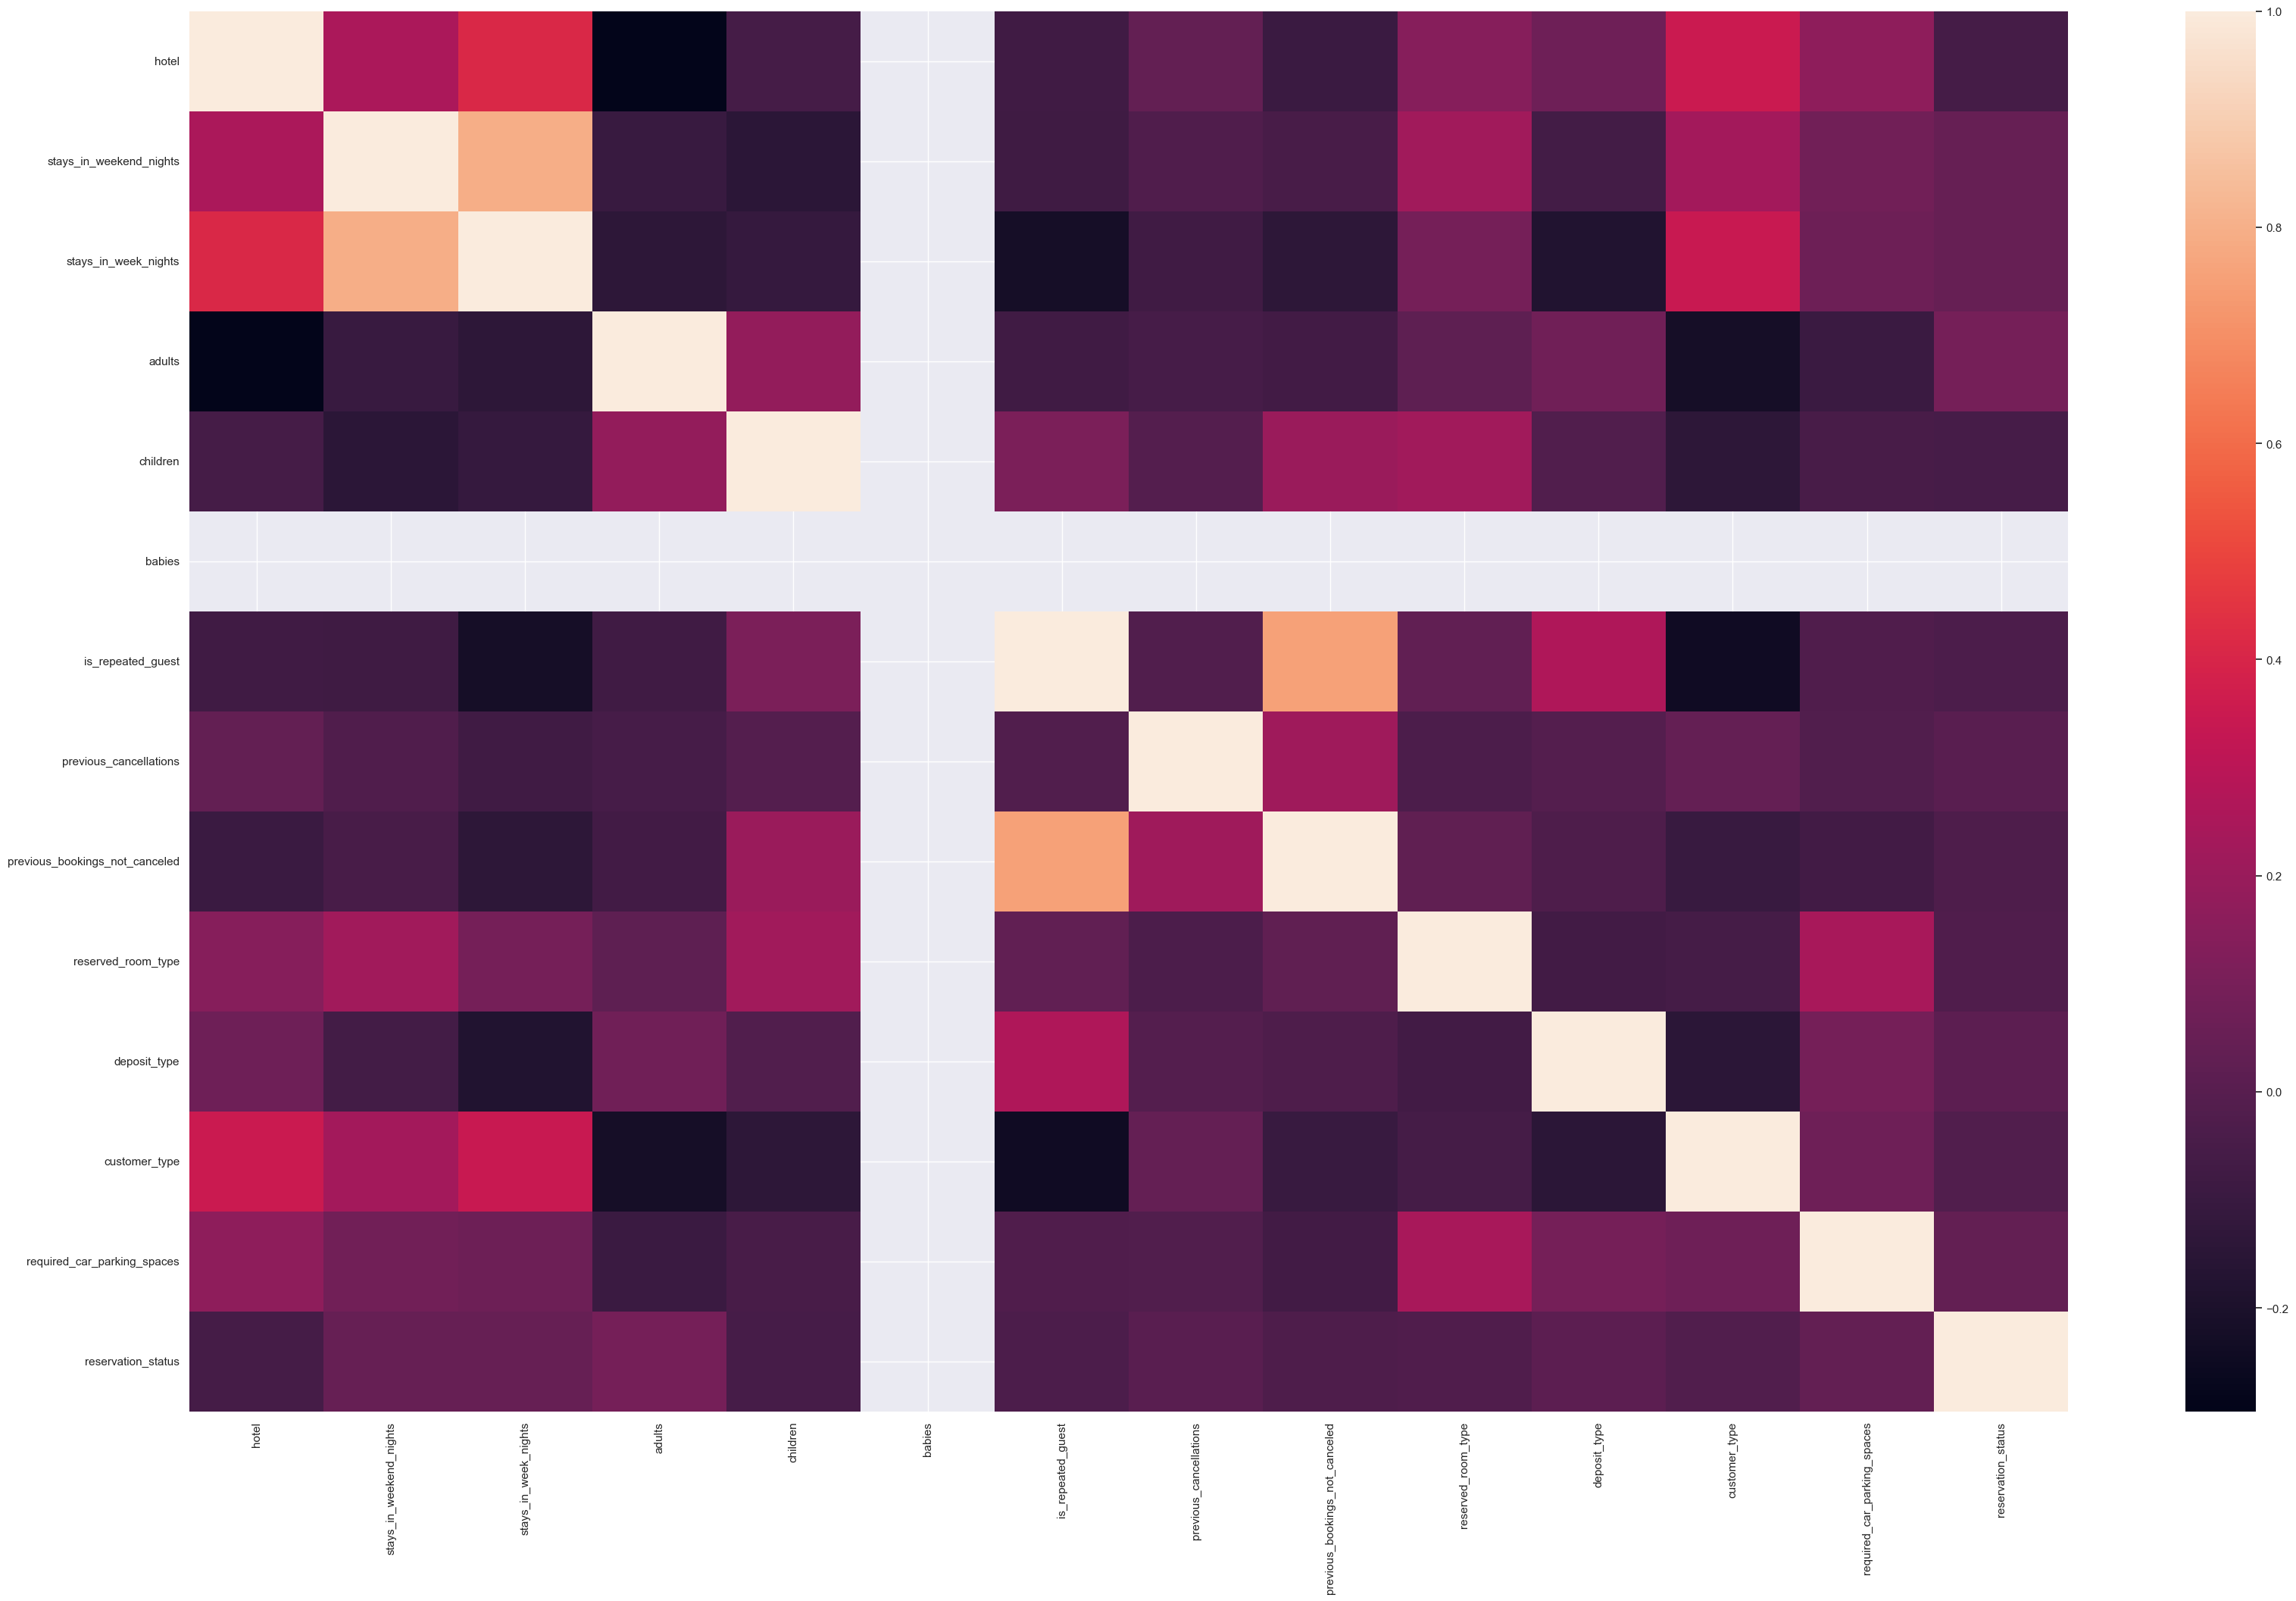

In [57]:
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
sns.heatmap(df.corr())
sns.set(rc={"figure.figsize":(40, 24)})

In [58]:
features=list(df)
features.remove("reservation_status")
print(features)

['hotel', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'reserved_room_type', 'deposit_type', 'customer_type', 'required_car_parking_spaces']


In [59]:
X=df[features]
y=df.reservation_status

In [60]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y)

In [61]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from sklearn import metrics
import time

In [62]:
#Tree with Gini Index

gini_clf=DecisionTreeClassifier(criterion="gini", random_state=5)

#Training Decision Tree Classifier
start = time.time()
gini_clf = gini_clf.fit(X_train, y_train)
stop = time.time()
print(f"Training time: {stop - start}s")

Training time: 0.015564918518066406s


In [70]:
from sklearn import tree
text_rep=tree.export_text(gini_clf)
print(text_rep)

|--- feature_1 <= 1.50
|   |--- feature_2 <= 2.50
|   |   |--- feature_3 <= 1.50
|   |   |   |--- feature_8 <= 1.50
|   |   |   |   |--- feature_11 <= 2.50
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- feature_11 >  2.50
|   |   |   |   |   |--- feature_1 <= 0.50
|   |   |   |   |   |   |--- feature_2 <= 1.50
|   |   |   |   |   |   |   |--- feature_3 <= 0.50
|   |   |   |   |   |   |   |   |--- class: 2
|   |   |   |   |   |   |   |--- feature_3 >  0.50
|   |   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |   |--- feature_2 >  1.50
|   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |--- feature_1 >  0.50
|   |   |   |   |   |   |--- class: 1
|   |   |   |--- feature_8 >  1.50
|   |   |   |   |--- feature_2 <= 1.50
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- feature_2 >  1.50
|   |   |   |   |   |--- feature_0 <= 0.50
|   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |--- feature_0 >  0.50
|   |   |   |   |   |   |--- class: 0
|   |  

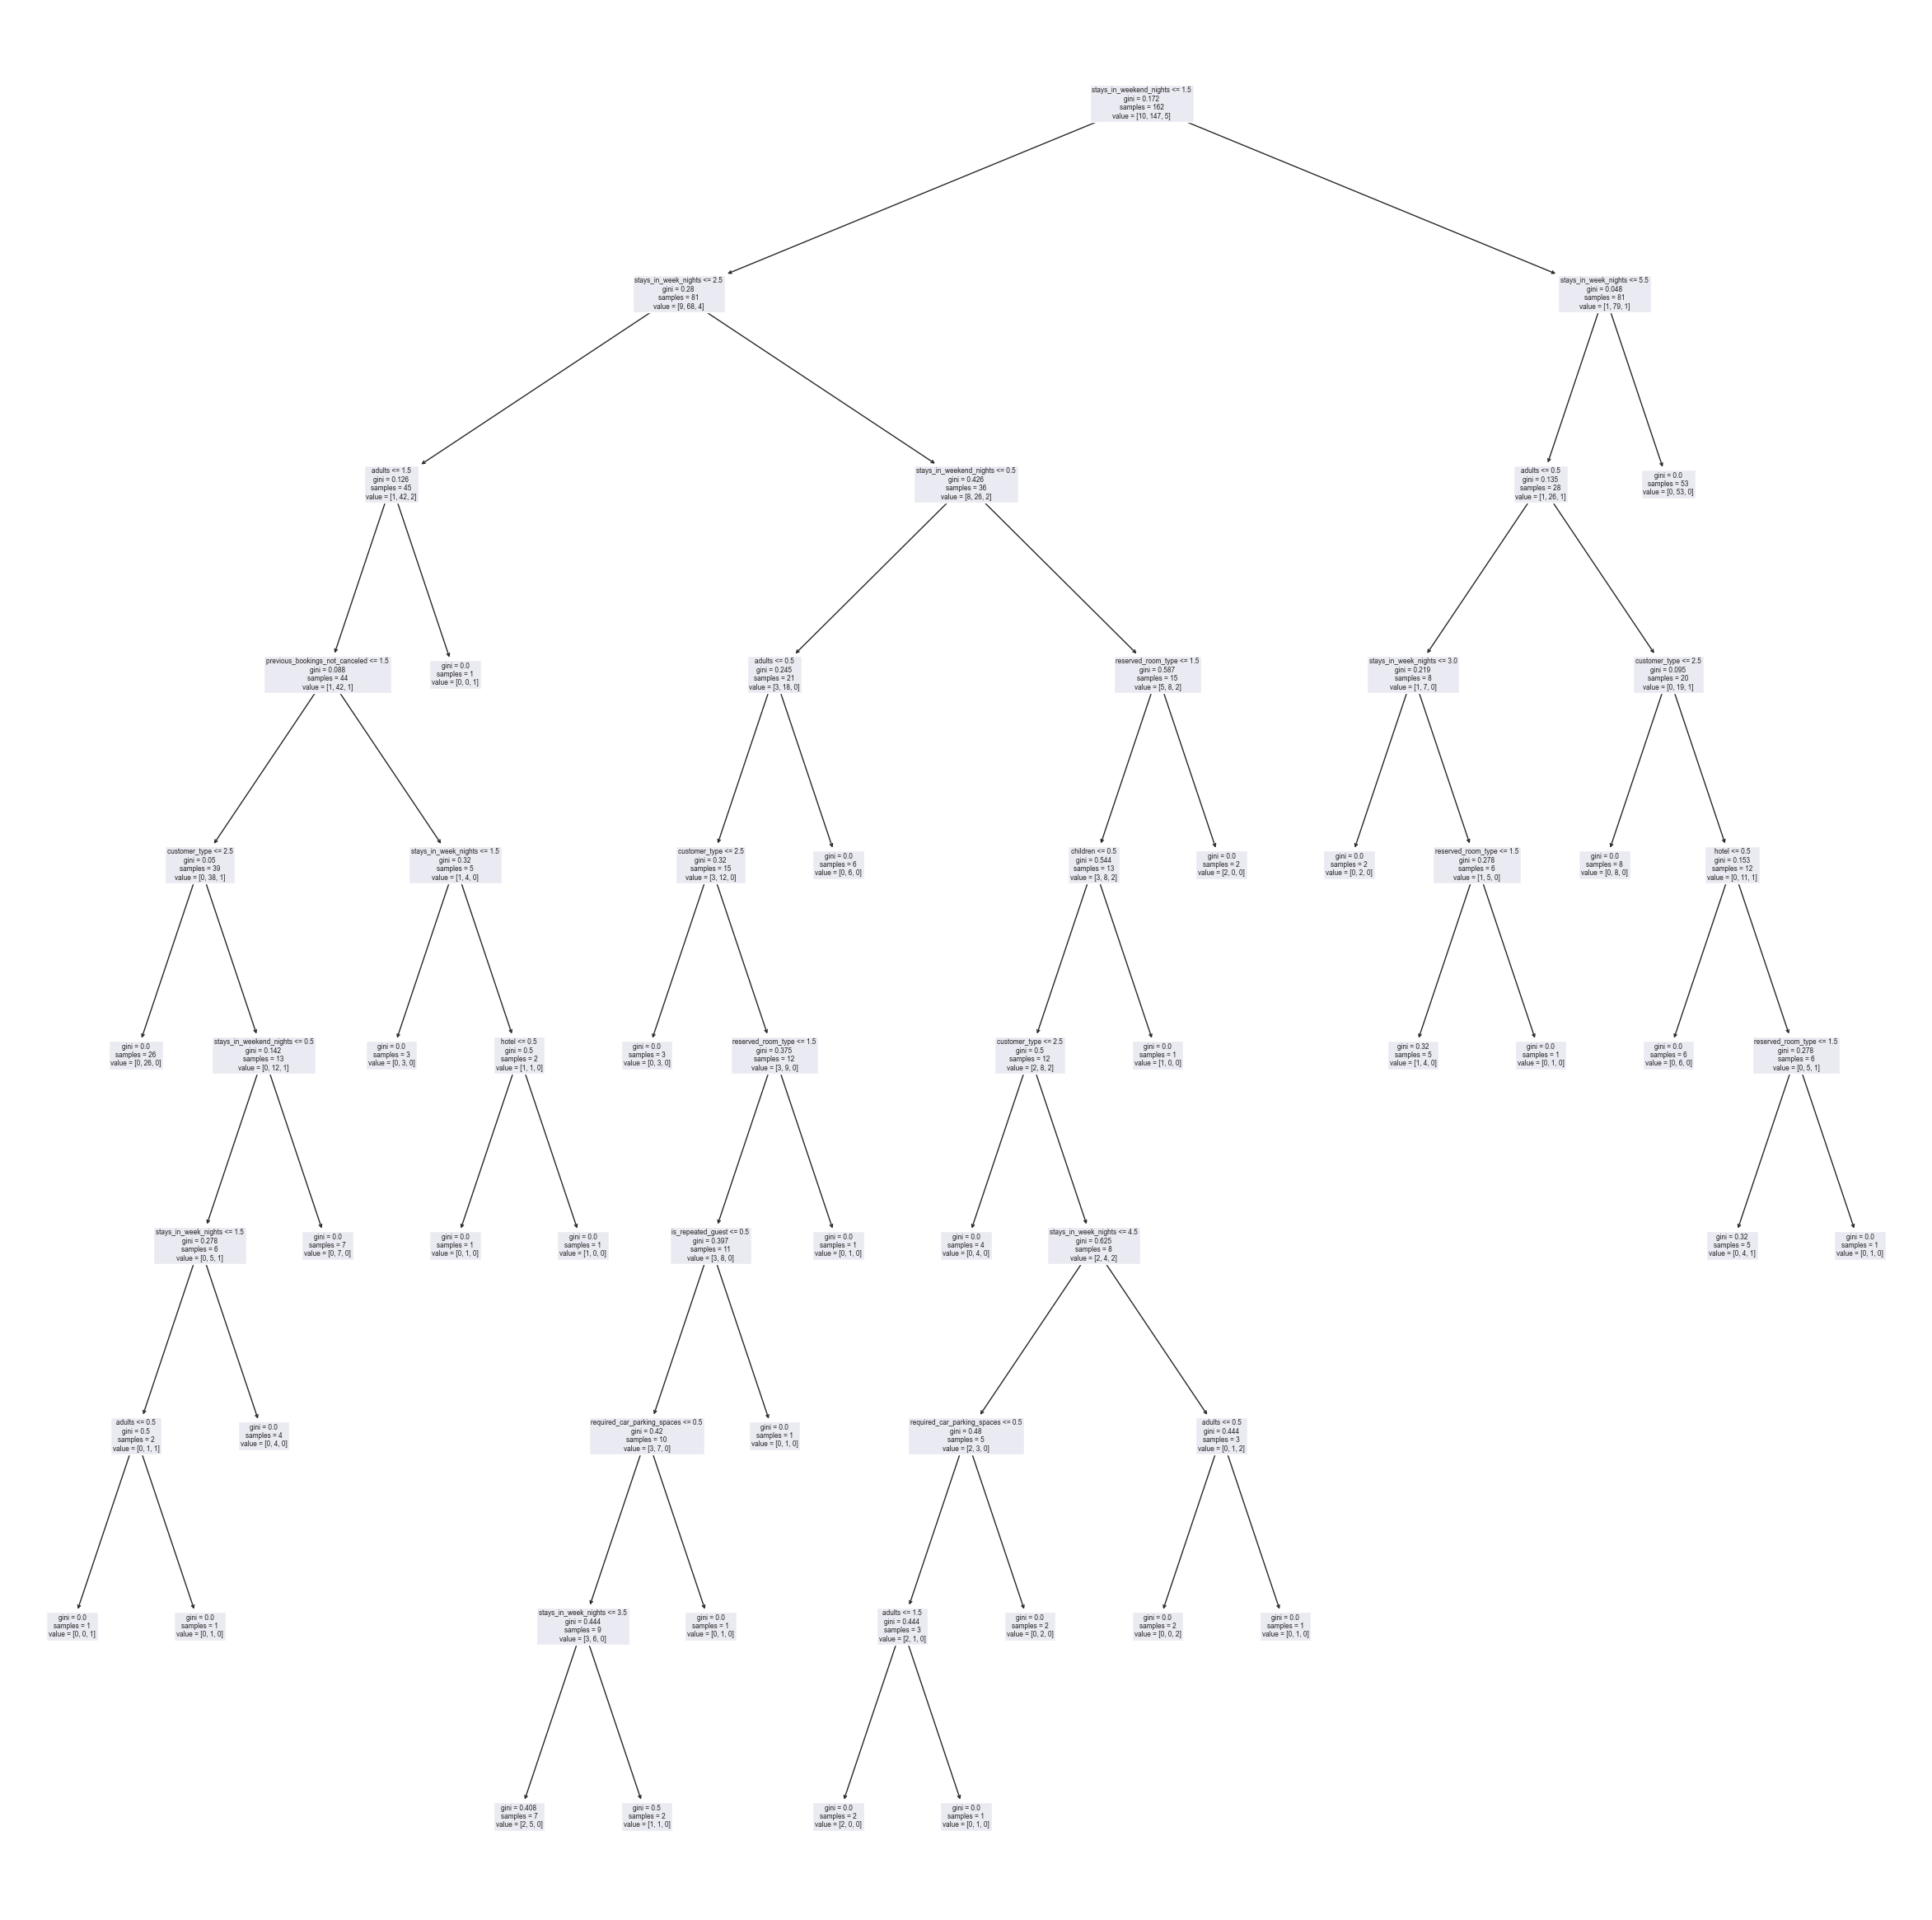

In [64]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

fig = plt.figure(figsize=(30, 30))
plot_tree(gini_clf, feature_names=X_train.columns.tolist(), class_names=None)
plt.show()


In [65]:
y_pred=gini_clf.predict(X_test)
print("Accuracy", metrics.accuracy_score(y_test, y_pred))

Accuracy 0.9454545454545454


In [66]:
ent_clf = DecisionTreeClassifier(criterion="entropy", random_state=5)

start = time.time()
ent_clf = ent_clf.fit(X_train, y_train)
stop = time.time()
print(f"Training time: {stop - start}s")

Training time: 0.0025529861450195312s


In [67]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=100, random_state=2)


start = time.time()
ent_clf = ent_clf.fit(X_train, y_train)
stop = time.time()
print(f"Training time: {stop - start}s")

Training time: 0.008008003234863281s


In [68]:
y_pred = ent_clf.predict(X_test)
print("Accuracy:", metrics.accuracy_score(y_test, y_pred))

Accuracy: 0.9272727272727272


In [69]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=100, random_state=2)


start = time.time()
ent_clf = ent_clf.fit(X_train, y_train)
rf_clt = rf.fit(X_train, y_train)
stop = time.time()
print(f"Training time: {stop - start}s")

Training time: 0.3512303829193115s


In [72]:
y_pred = rf.predict(X_test)
print("Accuracy:", metrics.accuracy_score(y_test, y_pred))

Accuracy: 0.9454545454545454
